### Configuration, inputs & outputs

In [1]:
from pipeline_utils import make_case1_paths, prepare_mouse_fit_data, plot_mouse_growth_fit
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]
FIGURES_DIR = paths["figures"]
FIGURES_SUPP_DIR = paths["figures_supp"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Load input data
experiment_file = RAW_DIR / "uhn_lung" / "experiment.csv"
experiment_df = pd.read_csv(experiment_file)

print(f"Loaded experiment data: {experiment_df.shape}")

# Define output file
out_table_mouse = PROC_DIR / "mouse_doubling_times_lung.csv"
out_table_mouse_qc = PROC_DIR / "mouse_doubling_times_qc_lung.csv"
out_table_model = PROC_DIR / "model_doubling_times_lung.csv"
out_table_model_qc = PROC_DIR / "model_doubling_times_qc_lung.csv"

# Doubling-time estimation parameters
MAX_DAY = 35       # use first 35 days to estimate exponential growth
MIN_POINTS = 3     # minimum number of time points per mouse
MIN_R2 = 0.8       # minimum log-linear fit quality

np.random.seed(101)


Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/procdata
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate
Loaded experiment data: (17021, 10)


### QC and dataset extraction

In [2]:
# Filter to parental, control-arm, positive-volume measurements
filter_summary = {
    "raw_measurements": len(experiment_df),
}

control_df = experiment_df.copy()

control_df = control_df[control_df["drug.id"] == "control"]
filter_summary["control_arm_measurements"] = len(control_df)

control_df = control_df[control_df["volume"] > 0]
filter_summary["positive_volume_measurements"] = len(control_df)

print(pd.Series(filter_summary))
print(f"Unique control-arm mice: {control_df['model.id'].nunique()}")

df_raw_exp = control_df

raw_measurements                17021
control_arm_measurements         5013
positive_volume_measurements     4944
dtype: int64
Unique control-arm mice: 495


### Fit early-phase log-linear growth models for each control-arm mouse

In [3]:
per_mouse = []
mouse_qc = []

for mouse_id, mouse_df in control_df.groupby("model.id"):
    fit_df = (
        mouse_df.loc[mouse_df["time"] <= MAX_DAY, ["time", "volume"]]
        .dropna()
        .sort_values("time")
    )

    # If multiple records exist for the same mouse/day, average volume first.
    fit_df = (
        fit_df.groupby("time", as_index=False)["volume"]
        .mean()
        .sort_values("time")
    )

    qc_record = {
        "mouse_id": mouse_id,
        "modelID_raw": mouse_id.split(".")[0],
        "n_points_early": fit_df.shape[0],
        "max_day_used": fit_df["time"].max() if not fit_df.empty else np.nan,
        "status": "retained",
        "reason_excluded": "keep", # default, will be updated if meet exclude criteria
    }

    if fit_df.shape[0] < MIN_POINTS:
        qc_record["status"] = "excluded"
        qc_record["reason_excluded"] = "too_few_points"
        mouse_qc.append(qc_record)
        continue

    slope, intercept, r, p_value, std_err = linregress(
        fit_df["time"],
        np.log(fit_df["volume"])
    )

    r2 = r**2

    if slope <= 0:
        qc_record["status"] = "excluded"
        qc_record["reason_excluded"] = "non_positive_slope"
        qc_record["growth_rate_k"] = slope
        qc_record["r2"] = r2
        mouse_qc.append(qc_record)
        continue

    if r2 < MIN_R2:
        qc_record["status"] = "excluded"
        qc_record["reason_excluded"] = "low_r2"
        qc_record["growth_rate_k"] = slope
        qc_record["r2"] = r2
        mouse_qc.append(qc_record)
        continue

    doubling_time = np.log(2) / slope

    per_mouse.append({
        "mouse_id": mouse_id,
        "modelID_raw": mouse_id.split(".")[1],
        "growth_rate_k": slope,
        "doubling_time_days": doubling_time,
        "r2": r2,
        "n_points": fit_df.shape[0],
        "max_day_used": fit_df["time"].max(),
        "intercept": intercept,
        "p_value": p_value,
        "std_err": std_err,
    })

    qc_record["growth_rate_k"] = slope
    qc_record["doubling_time_days"] = doubling_time
    qc_record["r2"] = r2
    mouse_qc.append(qc_record)

per_mouse_df = pd.DataFrame(per_mouse)
mouse_qc_df = pd.DataFrame(mouse_qc)

per_mouse_df.to_csv(out_table_mouse, index=False)
print(f"Mouse-level doubling-time table: {per_mouse_df.shape}")
print(f"Saved to: {out_table_mouse}")

mouse_qc_df.to_csv(out_table_mouse_qc, index=False)
print(f"Mouse-level doubling-time qc saved to: {out_table_mouse_qc}")
print(f"Retained mouse-level fits: {per_mouse_df.shape[0]}\n")
print(mouse_qc_df["reason_excluded"].value_counts(dropna=False))
display(per_mouse_df.head())
display(per_mouse_df.describe())

Mouse-level doubling-time table: (405, 10)
Saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/mouse_doubling_times_lung.csv
Mouse-level doubling-time qc saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/mouse_doubling_times_qc_lung.csv
Retained mouse-level fits: 405

reason_excluded
keep                  405
low_r2                 63
too_few_points         14
non_positive_slope     13
Name: count, dtype: int64


,mouse_id,modelID_raw,growth_rate_k,doubling_time_days,r2,n_points,max_day_used,intercept,p_value,std_err
0,f1.PHLC402.TPX.control.P603,PHLC402,0.062298,11.126326,0.856992,8,25,5.301549,0.000968,0.010389
1,f1.PHLC402.TPX.control.P607,PHLC402,0.067259,10.305688,0.949891,8,25,4.901225,0.000040,0.006307
2,f1.PHLC402.TPX.control.P608,PHLC402,0.096428,7.188265,0.928271,8,25,4.621815,0.000119,0.010943
3,f1.PHLC402.TPX.control.P609,PHLC402,0.078962,8.778219,0.909990,8,25,4.868978,0.000236,0.010138
4,f1.PHLC402.TPX.control.P610,PHLC402,0.065903,10.517609,0.897969,8,25,4.472554,0.000345,0.009069


,growth_rate_k,doubling_time_days,r2,n_points,max_day_used,intercept,p_value,std_err
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,4.050000e+02,405.000000
mean,0.079412,10.953815,0.942036,7.587654,24.382716,4.808658,4.040272e-03,0.008216
std,0.038814,6.000416,0.042361,2.167571,7.560921,1.533286,1.744616e-02,0.006536
min,0.015345,2.739017,0.801301,3.000000,6.000000,-6.642750,4.308157e-10,0.001026
25%,0.055177,7.393278,0.922437,6.000000,19.000000,4.673071,4.869128e-06,0.004502
50%,0.072232,9.596153,0.953851,8.000000,24.000000,5.141089,1.094394e-04,0.006609
75%,0.093754,12.562148,0.974006,9.000000,32.000000,5.436812,9.794605e-04,0.009949
max,0.253064,45.170651,0.999439,12.000000,35.000000,6.738368,2.085578e-01,0.067004


### Follow-up duration vs. growth rate (motivates a bounded MAX_DAY)

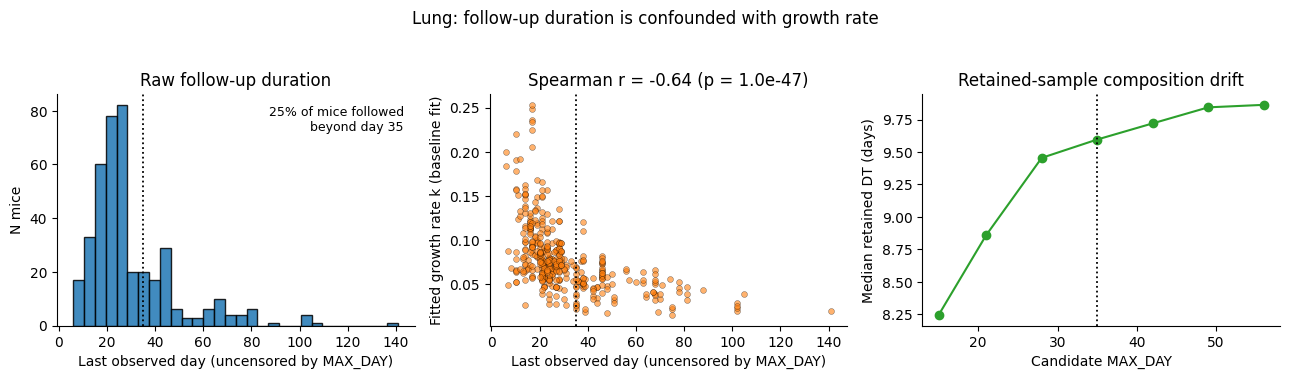

Saved follow-up censoring table to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/followup_censoring_lung.csv
Saved MAX_DAY composition-drift table to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/maxday_composition_drift_lung.csv
Saved follow-up censoring figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure1b_followup_censoring_lung.png


In [4]:
from pipeline_utils import (
    compute_followup_censoring,
    compute_maxday_composition_drift,
    plot_followup_censoring,
)

censoring_df = compute_followup_censoring(control_df, per_mouse_df)
drift_df = compute_maxday_composition_drift(
    control_df,
    max_day_grid=[15, 21, 28, 35, 42, 49, 56],
    min_points=MIN_POINTS,
    min_r2=MIN_R2,
    modelid_split_index=1,
)

out_table_followup_censoring = PROC_DIR / "followup_censoring_lung.csv"
out_table_maxday_drift = PROC_DIR / "maxday_composition_drift_lung.csv"
out_figure_followup_censoring = FIGURES_SUPP_DIR / "supp_figure1b_followup_censoring_lung.png"

censoring_df.to_csv(out_table_followup_censoring, index=False)
drift_df.to_csv(out_table_maxday_drift, index=False)
plot_followup_censoring(
    censoring_df, drift_df, max_day=MAX_DAY, out_path=out_figure_followup_censoring, cohort_label="Lung"
)
plt.show()

print(f"Saved follow-up censoring table to: {out_table_followup_censoring}")
print(f"Saved MAX_DAY composition-drift table to: {out_table_maxday_drift}")
print(f"Saved follow-up censoring figure to: {out_figure_followup_censoring}")

### QC threshold sensitivity (MIN_POINTS, MIN_R2)

One-parameter-at-a-time sweep against the pipeline defaults (`MIN_POINTS=3`, `MIN_R2=0.8`, dotted line in each panel; `MAX_DAY` fixed at 35).

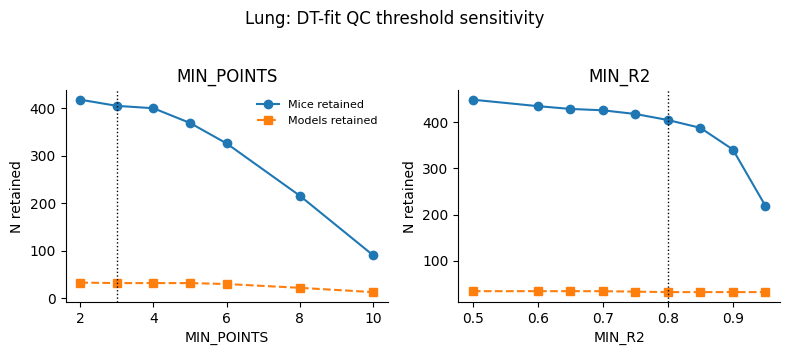

Saved sensitivity table to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/qc_threshold_sensitivity_lung.csv
Saved sensitivity figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure1a_qc_threshold_sensitivity_lung.png


,parameter,value,is_baseline,n_mice_retained,n_models_retained,median_doubling_time_days,mean_r2
1,MIN_POINTS,3.0,True,405,32,9.596153,0.942036
12,MIN_R2,0.8,True,405,32,9.596153,0.942036


In [5]:
from pipeline_utils import qc_threshold_sensitivity, plot_qc_threshold_sensitivity

min_points_grid = [2, 3, 4, 5, 6, 8, 10]
min_r2_grid = [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

sensitivity_df = qc_threshold_sensitivity(
    control_df,
    baseline_max_day=MAX_DAY,
    baseline_min_points=MIN_POINTS,
    baseline_min_r2=MIN_R2,
    min_points_grid=min_points_grid,
    min_r2_grid=min_r2_grid,
    modelid_split_index=1,
)

out_table_qc_sensitivity = PROC_DIR / "qc_threshold_sensitivity_lung.csv"
out_figure_qc_sensitivity = FIGURES_SUPP_DIR / "supp_figure1a_qc_threshold_sensitivity_lung.png"

sensitivity_df.to_csv(out_table_qc_sensitivity, index=False)
plot_qc_threshold_sensitivity(sensitivity_df, out_figure_qc_sensitivity, cohort_label="Lung")
plt.show()

print(f"Saved sensitivity table to: {out_table_qc_sensitivity}")
print(f"Saved sensitivity figure to: {out_figure_qc_sensitivity}")
display(sensitivity_df.loc[sensitivity_df["is_baseline"]])

### Visualize representative mouse-level growth fits

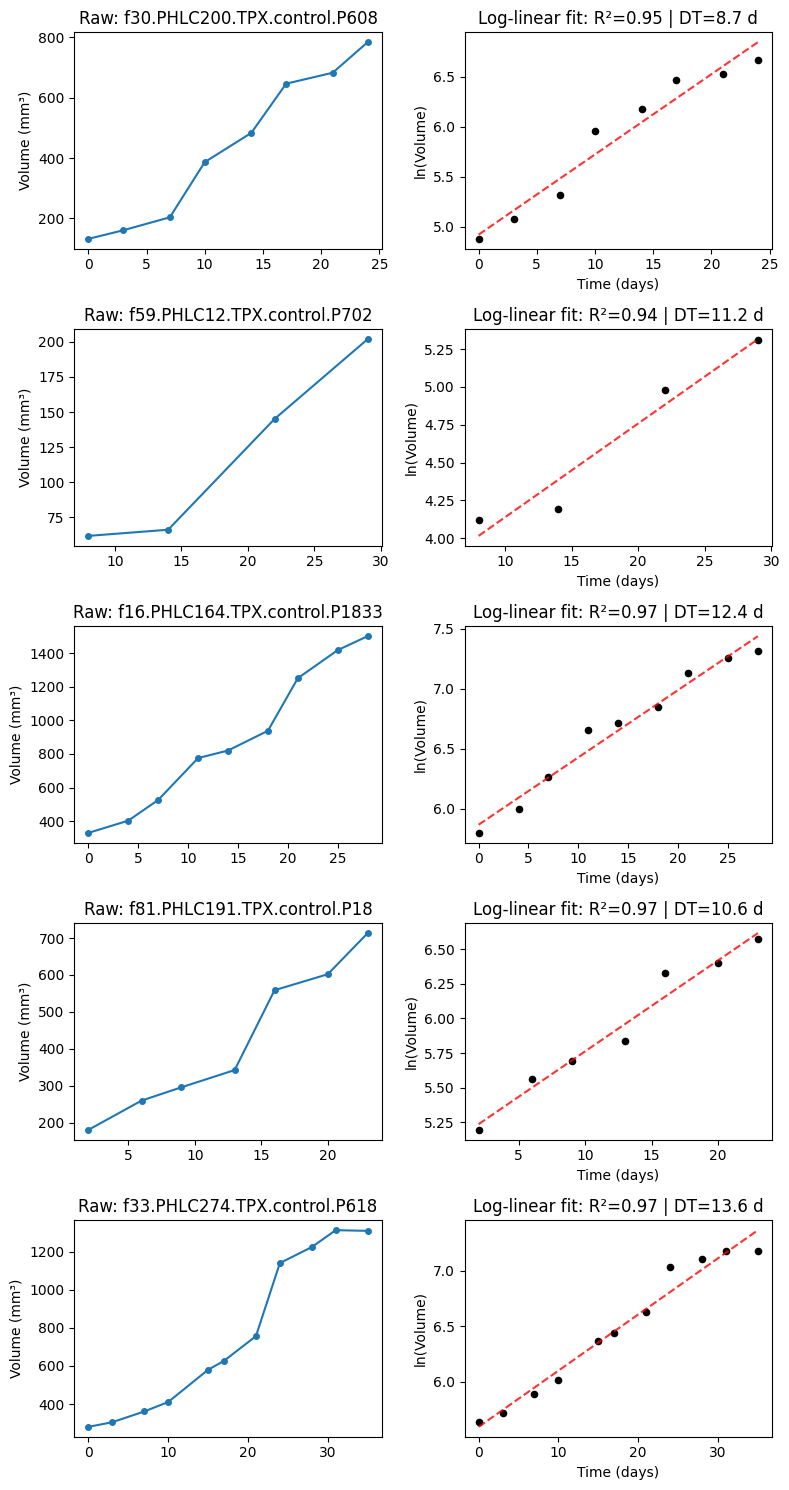

In [6]:
# Pick example mice from retained mouse-level fits
n_examples = 5
RANDOM_STATE = 101
rng = np.random.default_rng(RANDOM_STATE)

example_ids = rng.choice(
    per_mouse_df["mouse_id"],
    size=min(n_examples, per_mouse_df.shape[0]),
    replace=False,
)

fig, axes = plt.subplots(
    nrows=len(example_ids),
    ncols=2,
    figsize=(8, 3 * len(example_ids)),
    sharex=False,
)

if len(example_ids) == 1:
    axes = np.array([axes])

for i, mouse_id in enumerate(example_ids):
    plot_mouse_growth_fit(mouse_id, axes[i, 0], axes[i, 1], control_df)

plt.tight_layout()
plt.show()

### Fit early-phase log-linear growth models for each control-arm model

In [7]:
per_model_df = (
    per_mouse_df.groupby("modelID_raw")
    .agg(
        mean_growth_rate_k=("growth_rate_k", "mean"),
        sd_mouse_doubling_time=("doubling_time_days", "std"),
        n_mice=("mouse_id", "nunique"),
        mean_r2=("r2", "mean"),
        min_r2=("r2", "min"),
        max_day_used=("max_day_used", "max"),
    )
    .reset_index()
    .rename(columns={"modelID_raw": "modelID"})
)

numeric_model_mask = per_model_df["modelID"].str.match(r"^\d", na=False)
per_model_df.loc[numeric_model_mask, "modelID"] = (
    "S" + per_model_df.loc[numeric_model_mask, "modelID"]
)

per_model_df["doubling_time_days"] = np.log(2) / per_model_df["mean_growth_rate_k"]

per_model_df = per_model_df.sort_values("modelID").reset_index(drop=True)

per_model_df.to_csv(out_table_model, index=False)

print(f"Model-level doubling-time table: {per_model_df.shape}")
print(f"Saved to: {out_table_model}")

display(per_model_df.head())
display(per_model_df.describe())

Model-level doubling-time table: (32, 8)
Saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/model_doubling_times_lung.csv


,modelID,mean_growth_rate_k,sd_mouse_doubling_time,n_mice,mean_r2,min_r2,max_day_used,doubling_time_days
0,PHLC108,0.128438,0.821947,4,0.971875,0.937649,18,5.396734
1,PHLC110,0.040705,8.201176,6,0.925870,0.879807,32,17.028603
2,PHLC119,0.116137,3.634106,12,0.949711,0.867056,34,5.968340
3,PHLC12,0.047850,5.879595,29,0.926955,0.801573,35,14.485865
4,PHLC137,0.081728,4.493175,16,0.929583,0.843953,35,8.481142


,mean_growth_rate_k,sd_mouse_doubling_time,n_mice,mean_r2,min_r2,max_day_used,doubling_time_days
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.00000,32.000000
mean,0.081504,2.853132,12.656250,0.940654,0.871386,27.90625,11.024681
std,0.041870,2.209446,15.340458,0.021373,0.047462,7.05444,6.519645
min,0.021883,0.232739,2.000000,0.902041,0.801301,14.00000,2.968453
25%,0.054301,1.352902,5.000000,0.924397,0.831787,21.00000,6.662291
50%,0.077169,1.969453,6.000000,0.942877,0.868258,30.50000,8.983216
75%,0.104074,4.505183,14.000000,0.952065,0.897996,34.25000,12.766186
max,0.233505,8.223599,82.000000,0.987030,0.975417,35.00000,31.675815


### QC summary

In [8]:
qc_summary = pd.Series({
    "Total evaluable PDX models": len(per_model_df),
    "Models with >=2 mice": (per_model_df["n_mice"] >= 2).sum(),
    "Total retained mouse-level fits": per_model_df["n_mice"].sum(),
    "Median DT (days)": round(per_model_df["doubling_time_days"].median(), 2),
    "Mean DT (days)": round(per_model_df["doubling_time_days"].mean(), 2),
    "Min DT (days)": round(per_model_df["doubling_time_days"].min(), 2),
    "Max DT (days)": round(per_model_df["doubling_time_days"].max(), 2),
    "Fast models (DT < 10 days)": (per_model_df["doubling_time_days"] < 10).sum(),
    "Slow models (DT > 40 days)": (per_model_df["doubling_time_days"] > 40).sum(),
    "Mean mouse-level fit R2": round(per_model_df["mean_r2"].mean(), 3),
})

qc_summary.to_csv(out_table_model_qc)
print(f"Model-level doubling-time qc saved to: {out_table_model_qc}")

print(qc_summary)

Model-level doubling-time qc saved to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/model_doubling_times_qc_lung.csv
Total evaluable PDX models          32.000
Models with >=2 mice                32.000
Total retained mouse-level fits    405.000
Median DT (days)                     8.980
Mean DT (days)                      11.020
Min DT (days)                        2.970
Max DT (days)                       31.680
Fast models (DT < 10 days)          19.000
Slow models (DT > 40 days)           0.000
Mean mouse-level fit R2              0.941
dtype: float64
